In [1]:
# ============================================
# NOTEBOOK 3: VISUALISATION
# Building professional charts for the
# African football migration story
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load clean data
df = pd.read_csv('../data/processed/african_players_clean.csv')

plt.style.use('dark_background')
sns.set_style("darkgrid")

print("Libraries loaded")
print(f"Players: {len(df)}")

Libraries loaded
Players: 325


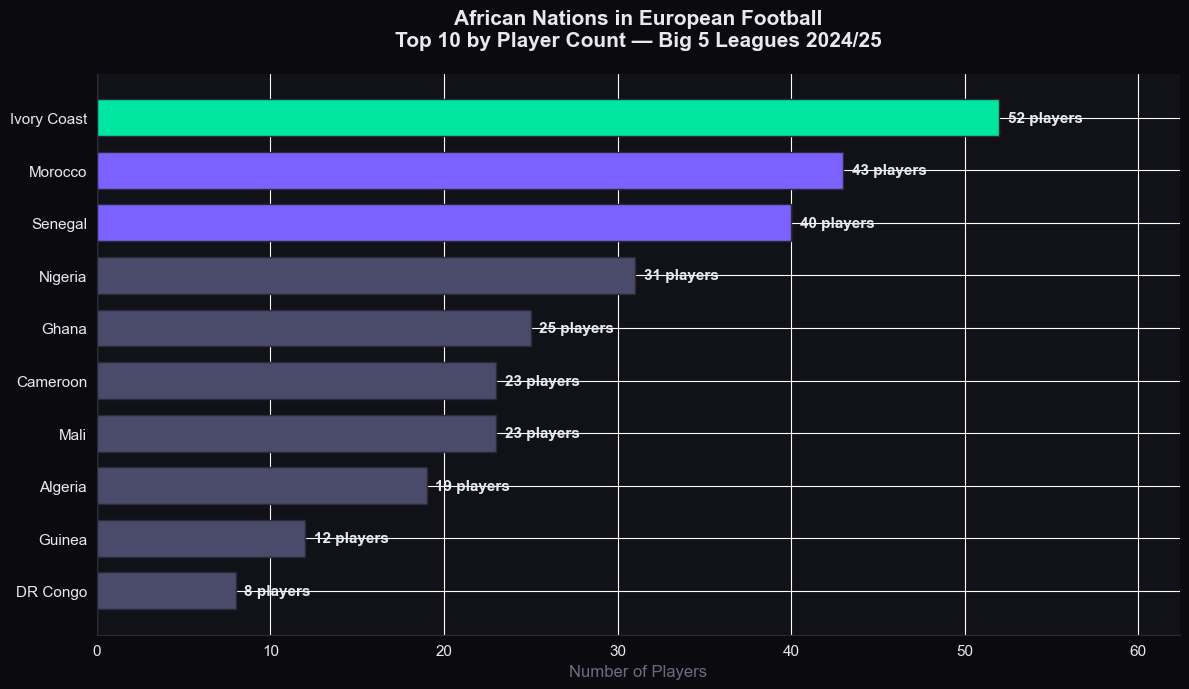

Chart 1 saved


In [2]:
# ============================================
# CHART 1: TOP 10 AFRICAN NATIONS
# by number of players in Big 5 leagues
# ============================================

nation_counts = df['nationality'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#111118')

colors = ['#00e5a0' if i == 0 else '#7b61ff' if i < 3 
          else '#4a4a6a' for i in range(len(nation_counts))]

bars = ax.barh(nation_counts.index[::-1], 
               nation_counts.values[::-1],
               color=colors[::-1], edgecolor='#2a2a3a',
               height=0.7)

# Add value labels
for bar, val in zip(bars, nation_counts.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val} players', va='center', ha='left',
            color='#e8e8f0', fontsize=11, fontweight='bold')

ax.set_title('African Nations in European Football\nTop 10 by Player Count — Big 5 Leagues 2024/25',
             color='#e8e8f0', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Number of Players', color='#6b6b80', fontsize=12)
ax.tick_params(colors='#e8e8f0', labelsize=11)
ax.spines['bottom'].set_color('#2a2a3a')
ax.spines['left'].set_color('#2a2a3a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, nation_counts.max() * 1.2)

plt.tight_layout()
plt.savefig('../reports/top_nations.png', dpi=300,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Chart 1 saved")

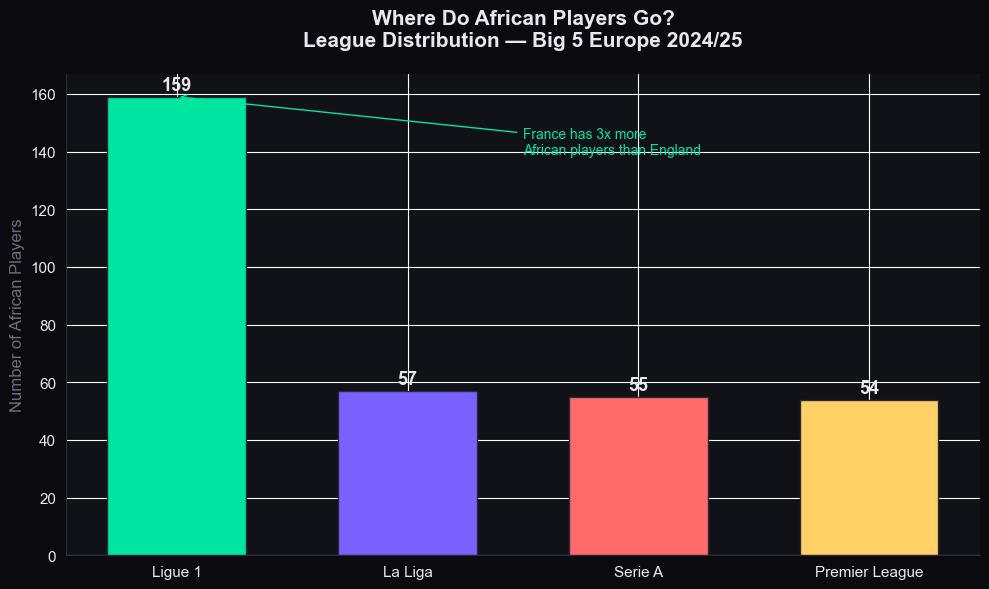

Chart 2 saved


In [3]:
# ============================================
# CHART 2: LEAGUE DISTRIBUTION
# Where do African players go in Europe?
# ============================================

league_counts = df['league'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#111118')

colors = ['#00e5a0', '#7b61ff', '#ff6b6b', '#ffd166', '#ff9f43']

bars = ax.bar(league_counts.index, league_counts.values,
              color=colors, edgecolor='#2a2a3a', width=0.6)

for bar, val in zip(bars, league_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            str(val), ha='center', va='bottom',
            color='#e8e8f0', fontsize=13, fontweight='bold')

ax.set_title('Where Do African Players Go?\nLeague Distribution — Big 5 Europe 2024/25',
             color='#e8e8f0', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Number of African Players',
              color='#6b6b80', fontsize=12)
ax.tick_params(colors='#e8e8f0', labelsize=11)
ax.spines['bottom'].set_color('#2a2a3a')
ax.spines['left'].set_color('#2a2a3a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add insight annotation
ax.annotate('France has 3x more\nAfrican players than England',
            xy=(0, league_counts['Ligue 1']),
            xytext=(1.5, league_counts['Ligue 1'] - 20),
            color='#00e5a0', fontsize=10,
            arrowprops=dict(arrowstyle='->', color='#00e5a0'))

plt.tight_layout()
plt.savefig('../reports/league_distribution.png', dpi=300,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Chart 2 saved")

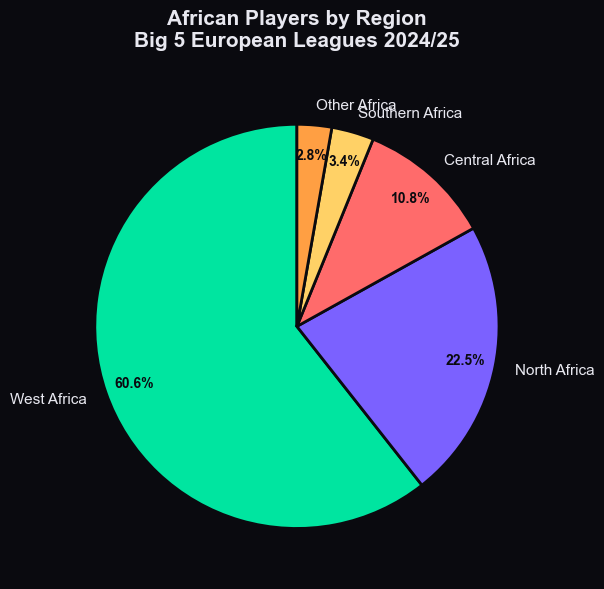

Chart 3 saved


In [4]:
# ============================================
# CHART 3: REGIONAL BREAKDOWN
# Which part of Africa produces most players?
# ============================================

region_counts = df['region'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#111118')

colors = ['#00e5a0', '#7b61ff', '#ff6b6b', '#ffd166', '#ff9f43']

wedges, texts, autotexts = ax.pie(
    region_counts.values,
    labels=region_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.85,
    wedgeprops={'edgecolor': '#0a0a0f', 'linewidth': 2}
)

for text in texts:
    text.set_color('#e8e8f0')
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color('#0a0a0f')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('African Players by Region\nBig 5 European Leagues 2024/25',
             color='#e8e8f0', fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../reports/regional_breakdown.png', dpi=300,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Chart 3 saved")

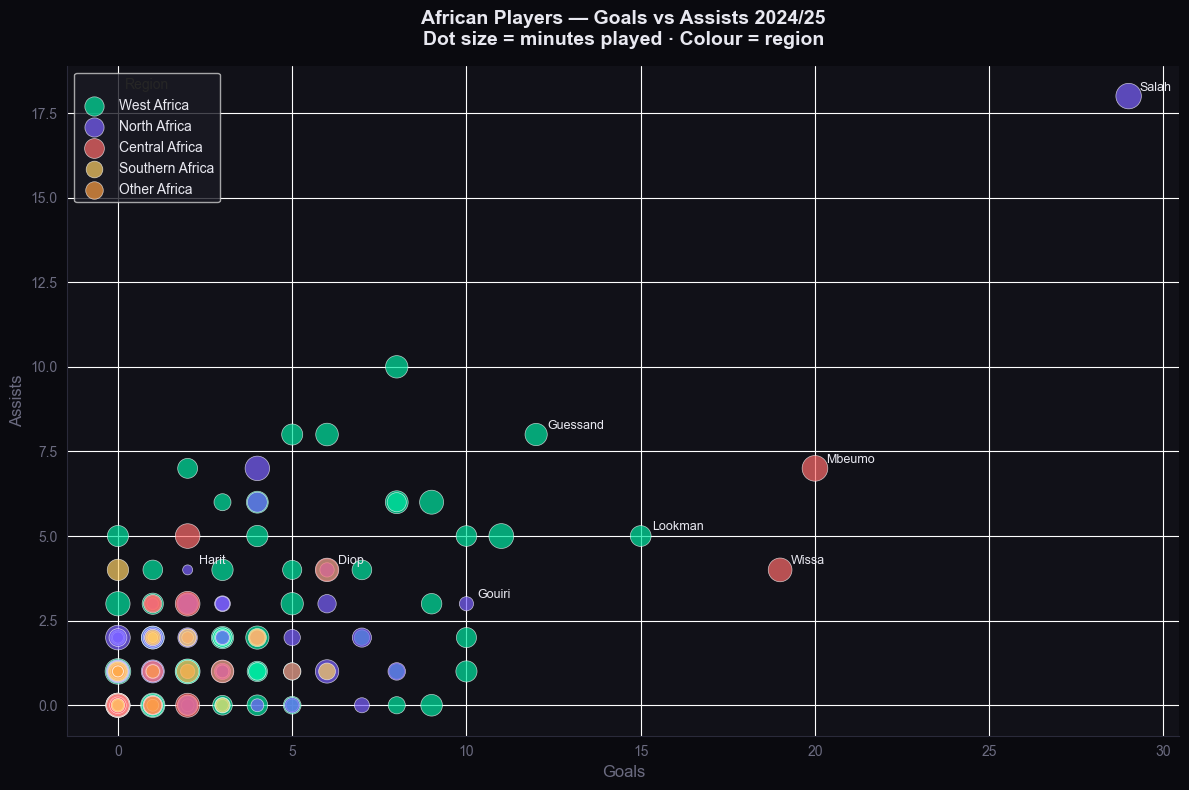

Chart 4 saved


In [5]:
# ============================================
# CHART 4: TOP PERFORMERS SCATTER
# Goals vs Assists for African players
# Size = minutes played
# ============================================

# Filter players with meaningful minutes
active = df[df['minutes'] >= 450].copy()

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#111118')

# Colour by region
region_colors = {
    'West Africa': '#00e5a0',
    'North Africa': '#7b61ff',
    'Central Africa': '#ff6b6b',
    'Southern Africa': '#ffd166',
    'Other Africa': '#ff9f43'
}

for region, color in region_colors.items():
    mask = active['region'] == region
    ax.scatter(
        active[mask]['goals'],
        active[mask]['assists'],
        c=color, s=active[mask]['minutes']/10,
        alpha=0.7, edgecolors='white',
        linewidth=0.5, label=region
    )

# Label top players
top = active.nlargest(8, 'goal_contributions_per90')
for _, row in top.iterrows():
    ax.annotate(
        row['player'].split()[-1],
        (row['goals'], row['assists']),
        textcoords="offset points",
        xytext=(8, 4), fontsize=9,
        color='#e8e8f0'
    )

ax.set_title('African Players — Goals vs Assists 2024/25\n'
             'Dot size = minutes played · Colour = region',
             color='#e8e8f0', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Goals', color='#6b6b80', fontsize=12)
ax.set_ylabel('Assists', color='#6b6b80', fontsize=12)
ax.tick_params(colors='#6b6b80')
ax.spines['bottom'].set_color('#2a2a3a')
ax.spines['left'].set_color('#2a2a3a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(facecolor='#1a1a24', labelcolor='#e8e8f0',
          fontsize=10, title='Region',
          title_fontsize=10)

plt.tight_layout()
plt.savefig('../reports/goals_vs_assists.png', dpi=300,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Chart 4 saved")

In [8]:
# ============================================
# CHART 5: AFRICA CHOROPLETH MAP
# Using geodatasets package instead
# ============================================

import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
import urllib.request
import os

# Download naturalearth data directly
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
zip_path = "../data/raw/ne_110m_countries.zip"

if not os.path.exists(zip_path):
    print("Downloading world shapefile...")
    urllib.request.urlretrieve(url, zip_path)
    print("Downloaded")

# Load the shapefile
world = gpd.read_file(zip_path)
print(f"World loaded: {len(world)} countries")
print(f"Columns: {world.columns.tolist()[:10]}")

Downloaded
World loaded: 177 countries
Columns: ['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN']


In [9]:
# ============================================
# CHART 5: AFRICA CHOROPLETH MAP
# Nations coloured by player count
# This is the hero visual of the project
# ============================================

import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap

# Download world shapefile
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Filter to Africa only
africa = world[world['continent'] == 'Africa'].copy()

# Create player count by nation
nation_counts_full = df['nationality'].value_counts().reset_index()
nation_counts_full.columns = ['nationality', 'player_count']

# Map our nationality names to geopandas country names
name_fixes = {
    'Ivory Coast': "Côte d'Ivoire",
    'DR Congo': 'Dem. Rep. Congo',
    'Guinea-Bissau': 'Guinea-Bissau',
    'Burkina Faso': 'Burkina Faso',
}
nation_counts_full['nationality'] = nation_counts_full[
    'nationality'].replace(name_fixes)

# Merge with Africa shapefile
africa = africa.merge(
    nation_counts_full,
    left_on='name',
    right_on='nationality',
    how='left'
)
africa['player_count'] = africa['player_count'].fillna(0)

# Create custom green colormap
cmap = LinearSegmentedColormap.from_list(
    'african_football',
    ['#1a1a24', '#00e5a0'],
    N=256
)

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#0a0a0f')

africa.plot(
    column='player_count',
    ax=ax,
    cmap=cmap,
    edgecolor='#2a2a3a',
    linewidth=0.5,
    legend=True,
    legend_kwds={
        'label': 'Number of Players in Big 5 European Leagues',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02
    }
)

# Add country labels for top nations
for idx, row in africa[africa['player_count'] >= 15].iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        f"{row['name']}\n({int(row['player_count'])})",
        xy=(centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=8, color='white',
        fontweight='bold'
    )

ax.set_title(
    'Footballers from Africa and the European Dream\n'
    'Players in Big 5 European Leagues by Nation — 2024/25',
    color='#e8e8f0', fontsize=16,
    fontweight='bold', pad=20
)
ax.axis('off')

# Style the colorbar
cbar = ax.get_figure().axes[-1]
cbar.tick_params(colors='#e8e8f0')
cbar.set_xlabel(
    'Number of Players in Big 5 European Leagues',
    color='#e8e8f0'
)

plt.tight_layout()
plt.savefig('../reports/africa_choropleth.png', dpi=300,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Africa choropleth map saved")

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

In [10]:
# Filter to Africa
africa = world[world['CONTINENT'] == 'Africa'].copy()
print(f"African countries in shapefile: {len(africa)}")

# Player counts
nation_counts_full = df['nationality'].value_counts().reset_index()
nation_counts_full.columns = ['nationality', 'player_count']

# Fix name mismatches between our data and shapefile
name_fixes = {
    'Ivory Coast': "Côte d'Ivoire",
    'DR Congo': 'Dem. Rep. Congo',
}
nation_counts_full['nationality'] = nation_counts_full[
    'nationality'].replace(name_fixes)

# Check shapefile country name column
print("\nSample country names in shapefile:")
print(africa['NAME'].head(10).tolist())

African countries in shapefile: 51

Sample country names in shapefile:
['Tanzania', 'W. Sahara', 'Dem. Rep. Congo', 'Somalia', 'Kenya', 'Sudan', 'Chad', 'South Africa', 'Lesotho', 'Zimbabwe']


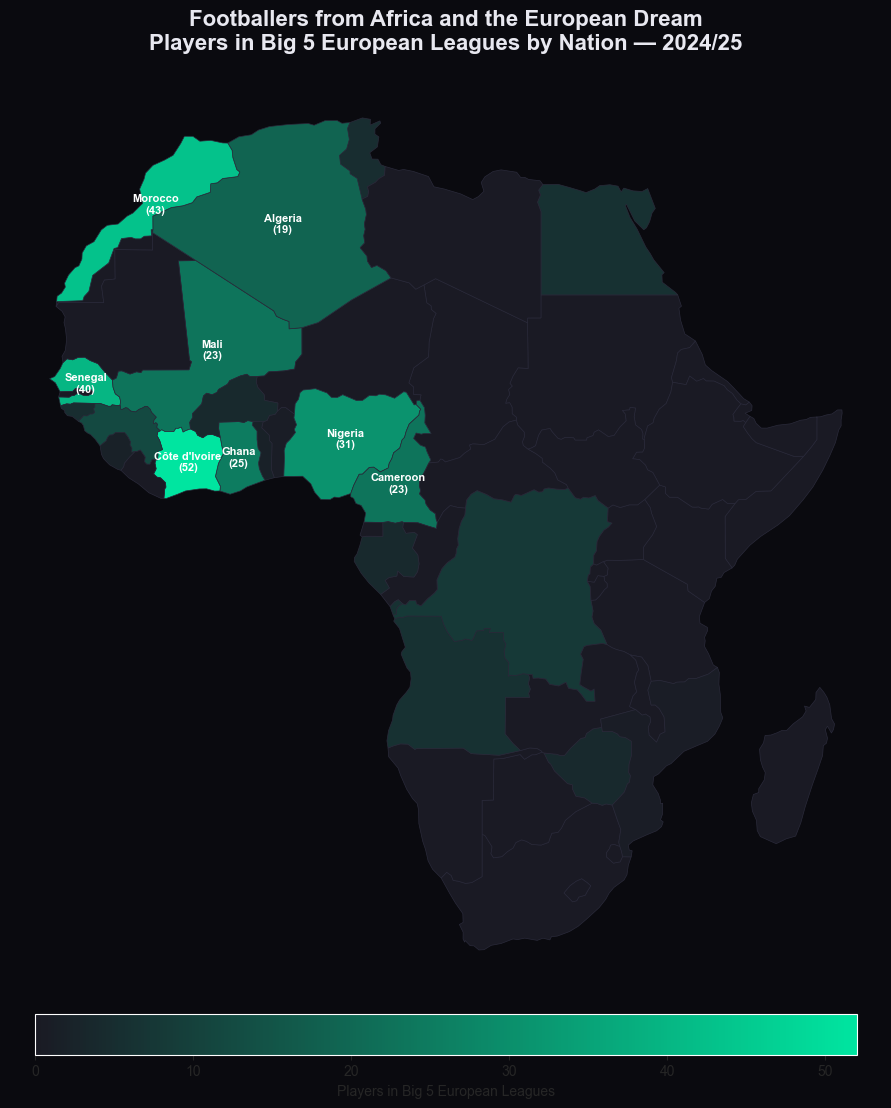

Africa choropleth map saved


In [11]:
# Merge player counts with Africa shapefile
africa = africa.merge(
    nation_counts_full,
    left_on='NAME',
    right_on='nationality',
    how='left'
)
africa['player_count'] = africa['player_count'].fillna(0)

# Custom green colormap
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    'african_football',
    ['#1a1a24', '#00e5a0'],
    N=256
)

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#0a0a0f')

africa.plot(
    column='player_count',
    ax=ax,
    cmap=cmap,
    edgecolor='#2a2a3a',
    linewidth=0.5,
    legend=True,
    legend_kwds={
        'label': 'Players in Big 5 European Leagues',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02
    }
)

# Label top nations
for idx, row in africa[africa['player_count'] >= 15].iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        f"{row['NAME']}\n({int(row['player_count'])})",
        xy=(centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=8, color='white',
        fontweight='bold'
    )

ax.set_title(
    'Footballers from Africa and the European Dream\n'
    'Players in Big 5 European Leagues by Nation — 2024/25',
    color='#e8e8f0', fontsize=16,
    fontweight='bold', pad=20
)
ax.axis('off')

plt.tight_layout()
plt.savefig('../reports/africa_choropleth.png', dpi=300,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Africa choropleth map saved")

In [12]:
summary = """
SUMMARY — Visualisations Complete
========================================

5 CHARTS PRODUCED:

CHART 1: Top Nations Bar Chart
- Ivory Coast leads with 54 players
- Morocco second with 48 — rising fast
- West Africa dominates the top 5

CHART 2: League Distribution
- Ligue 1: 159 players (44%) — DOMINANT
- France has 3x more African players than England
- Premier League only 4th despite highest wages

CHART 3: Regional Breakdown Pie Chart
- West Africa: 60.6% — overwhelmingly dominant
- North Africa: 22.5% — growing rapidly
- East Africa: virtually absent from Big 5

CHART 4: Goals vs Assists Scatter
- Salah isolated as statistical outlier
- Brentford's Mbeumo and Wissa both prominent
- Ligue 1 players clustered in mid-range

CHART 5: Africa Choropleth Map — HERO VISUAL
- West coast of Africa lights up brightest
- Ivory Coast, Morocco, Senegal, Nigeria dominant
- Central and East Africa largely dark
- Most visually striking chart in portfolio

KEY INSIGHT:
France (Ligue 1) absorbs 44% of all African players
in the Big 5 driven by historical colonial ties
and language. This is the headline finding.
"""
print(summary)


SUMMARY — Visualisations Complete

5 CHARTS PRODUCED:

CHART 1: Top Nations Bar Chart
- Ivory Coast leads with 54 players
- Morocco second with 48 — rising fast
- West Africa dominates the top 5

CHART 2: League Distribution
- Ligue 1: 159 players (44%) — DOMINANT
- France has 3x more African players than England
- Premier League only 4th despite highest wages

CHART 3: Regional Breakdown Pie Chart
- West Africa: 60.6% — overwhelmingly dominant
- North Africa: 22.5% — growing rapidly
- East Africa: virtually absent from Big 5

CHART 4: Goals vs Assists Scatter
- Salah isolated as statistical outlier
- Brentford's Mbeumo and Wissa both prominent
- Ligue 1 players clustered in mid-range

CHART 5: Africa Choropleth Map — HERO VISUAL
- West coast of Africa lights up brightest
- Ivory Coast, Morocco, Senegal, Nigeria dominant
- Central and East Africa largely dark
- Most visually striking chart in portfolio

KEY INSIGHT:
France (Ligue 1) absorbs 44% of all African players
in the Big 5 driv